In [22]:
# Import libraries for data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Importing libraries for model
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [23]:
df = pd.read_csv('Mall_Customers.csv') # Load the mall customers dataset
df.head() # Display first 5 rows of dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [24]:
df.info() # Display dataset information such as data types and non-null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [25]:
df.describe() # Display Statistical summary

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [26]:
df.isnull().sum() # Check if there are any missing values in the dataset

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


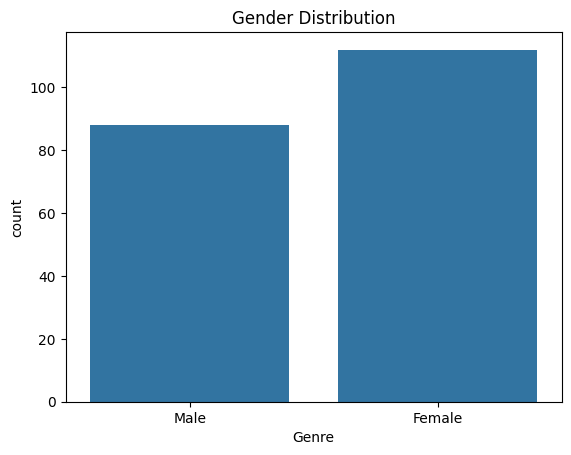

In [27]:
sns.countplot(x='Genre', data=df) # Plot count of male and female customers
plt.title("Gender Distribution")
plt.show()

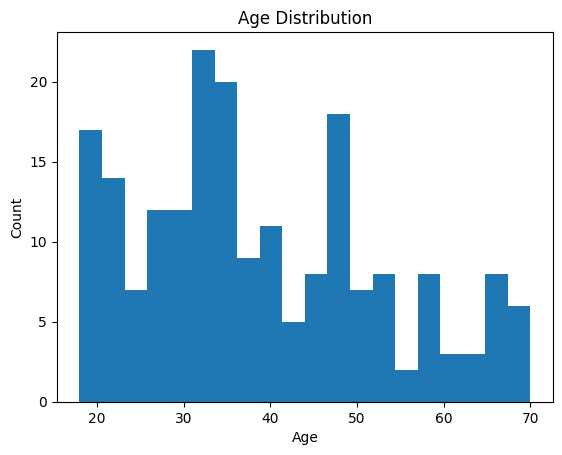

In [28]:
plt.hist(df['Age'], bins=20) # Create histogram to observe distribution of customer age
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

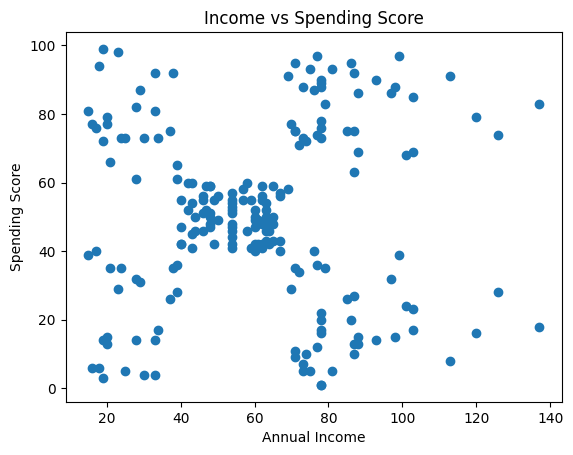

In [29]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)']) # Scatter plot to visualize relationship between income and spending score
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Income vs Spending Score")
plt.show()

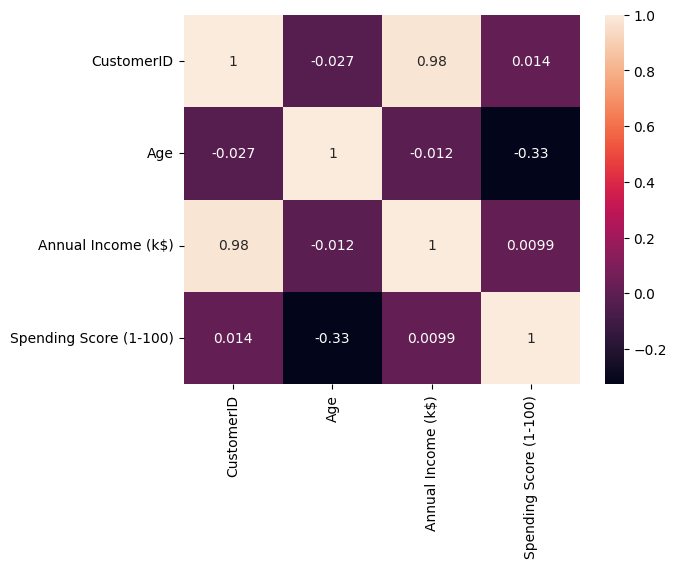

In [30]:
sns.heatmap(df.corr(numeric_only=True), annot=True) # Generate correlation matrix and visualize it using heatmap
plt.show()

In [31]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']] # Select important features

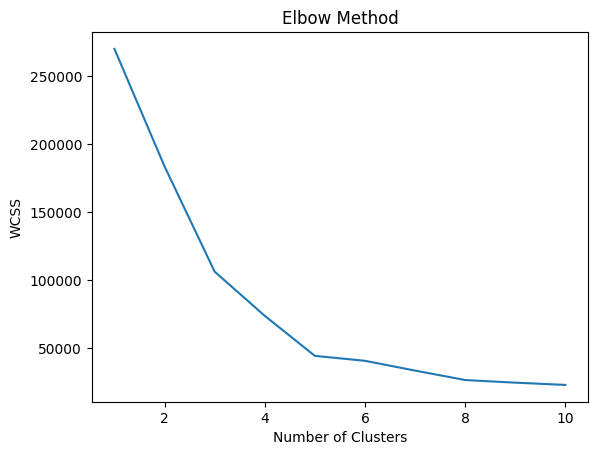

In [32]:
wcss = [] # List to store WCSS values

for i in range(1,11): # Test cluster numbers from 1 to 10
    kmeans = KMeans(n_clusters=i, random_state=42) # Train KMeans model
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)  # Store inertia (WCSS)

plt.plot(range(1,11), wcss) # Plot elbow graph
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [33]:
kmeans = KMeans(n_clusters=5, random_state=42) # Create KMeans model with 5 clusters
df['Cluster'] = kmeans.fit_predict(X)

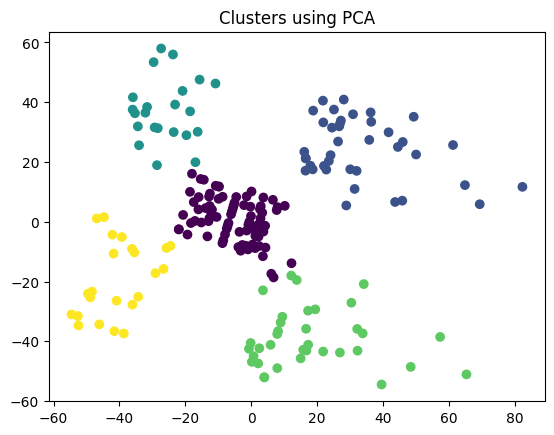

In [34]:
pca = PCA(n_components=2) # Create PCA model with 2 components
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Cluster'], cmap='viridis') # Plot PCA visualization
plt.title("Clusters using PCA")
plt.show()